# Technical Documentation Assistant (RAG)


In [1]:
!pip install -q langchain-community langchain-chroma langchain-text-splitters chromadb pypdf sentence-transformers transformers torch accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.3/206.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving python_beginners_guide.pdf to python_beginners_guide.pdf


In [3]:
pdf_path = list(uploaded.keys())[0]
print(pdf_path)

python_beginners_guide.pdf


In [4]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_chroma import Chroma

loader = PyPDFLoader(pdf_path)
documents = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=20)
chunks = splitter.split_documents(documents)

embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')
vectordb = Chroma.from_documents(documents=chunks, embedding=embeddings)

print('Chunks:', len(chunks))

/tmp/ipykernel_1653/392455385.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
/tmp/ipykernel_1653/392455385.py:12: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Chunks: 109


In [5]:
from transformers import pipeline
llm = pipeline('text-generation', model='TinyLlama/TinyLlama-1.1B-Chat-v1.0')

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.20GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [6]:
question = input('Enter Question: ')
retrieved_docs = vectordb.similarity_search(question, k=10)

unique_docs=[]
seen=set()
for doc in retrieved_docs:
    content=doc.page_content.strip()
    if content not in seen:
        seen.add(content)
        unique_docs.append(doc)
    if len(unique_docs)==3:
        break

context='\n\n'.join([d.page_content for d in unique_docs])

prompt=f'''You are a Technical Documentation Assistant. Answer ONLY from the documentation context. If not found, say: I could not find this information in the uploaded documentation.\n\nContext:\n{context}\n\nQuestion:\n{question}\n\nAnswer:'''

result=llm(prompt,max_new_tokens=150,do_sample=False)
print(result[0]['generated_text'])

Enter Question: what is python


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer LlamaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


You are a Technical Documentation Assistant. Answer ONLY from the documentation context. If not found, say: I could not find this information in the uploaded documentation.

Context:
1. Introduction to Python
Python is a general-purpose, high-level programming language created by Guido van Rossum and first
released in 1991. It emphasizes readability, a clean syntax, and a philosophy summarized in the "Zen

of Python": code should be simple, explicit, and easy to understand. Because of this design philosophy,
Python has become one of the most widely used languages in the world, spanning web development,
data analysis, automation, scientific computing, and artificial intelligence.

Python Programming — A Beginner's Guide
Page 7 of 20

Question:
what is python

Answer:
Python is a programming language that is easy to learn and use. It is a high-level language that is
designed to be easy to read and understand. Python is a general-purpose language that can be used for
various applications,

In [7]:
for i,doc in enumerate(unique_docs,1):
    print(f'\nReference {i} (Page {doc.metadata.get("page",0)+1})')
    print(doc.page_content[:700])


Reference 1 (Page 3)
1. Introduction to Python
Python is a general-purpose, high-level programming language created by Guido van Rossum and first
released in 1991. It emphasizes readability, a clean syntax, and a philosophy summarized in the "Zen

Reference 2 (Page 3)
of Python": code should be simple, explicit, and easy to understand. Because of this design philosophy,
Python has become one of the most widely used languages in the world, spanning web development,
data analysis, automation, scientific computing, and artificial intelligence.

Reference 3 (Page 7)
Python Programming — A Beginner's Guide
Page 7 of 20


# CRAG (Corrective RAG) Extension

In [8]:

# CRAG Retrieval Function
def crag_retrieve(question, vectordb, threshold=0.55):
    results = vectordb.similarity_search_with_relevance_scores(question, k=10)

    avg_score = sum(score for _, score in results[:3]) / min(3, len(results))

    if avg_score < threshold:
        print("Low retrieval confidence detected -> retrieving more chunks")
        results = vectordb.similarity_search_with_relevance_scores(question, k=20)

    docs = []
    seen = set()

    for doc, score in results:
        text = doc.page_content.strip()
        if text not in seen:
            seen.add(text)
            docs.append((doc, score))

        if len(docs) == 5:
            break

    return docs, avg_score


In [9]:

# CRAG Question Answering

question = input("Enter Question for CRAG: ")

crag_docs, confidence = crag_retrieve(question, vectordb)

context = "\n\n".join([d.page_content for d, _ in crag_docs])

prompt = f'''
You are a Technical Documentation Assistant.
Answer ONLY from the documentation context.
If the answer is not present, say:
I could not find this information in the uploaded documentation.

Context:
{context}

Question:
{question}

Answer:
'''

result = llm(prompt, max_new_tokens=150, do_sample=False)

print("\nCRAG ANSWER\n")
print(result[0]["generated_text"])
print("\nRetrieval Confidence:", confidence)


Enter Question for CRAG: what is python


[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



CRAG ANSWER


You are a Technical Documentation Assistant.
Answer ONLY from the documentation context.
If the answer is not present, say:
I could not find this information in the uploaded documentation.

Context:
1. Introduction to Python
Python is a general-purpose, high-level programming language created by Guido van Rossum and first
released in 1991. It emphasizes readability, a clean syntax, and a philosophy summarized in the "Zen

of Python": code should be simple, explicit, and easy to understand. Because of this design philosophy,
Python has become one of the most widely used languages in the world, spanning web development,
data analysis, automation, scientific computing, and artificial intelligence.

Python Programming — A Beginner's Guide
Page 7 of 20

Python Programming — A Beginner's Guide
Page 13 of 20

Python Programming — A Beginner's Guide
Page 4 of 20

Question:
what is python

Answer:
python is a general-purpose, high-level programming language created by guido van r

# Base RAG vs CRAG Evaluation

In [10]:

import pandas as pd
import time

test_questions = [
    "What is Python?",
    "What is a list?",
    "What is a dictionary?",
    "What is a tuple?",
    "Explain functions."
]

results = []

for q in test_questions:

    start = time.time()
    base_docs = vectordb.similarity_search(q, k=3)
    base_time = time.time() - start

    start = time.time()
    crag_docs, conf = crag_retrieve(q, vectordb)
    crag_time = time.time() - start

    results.append({
        "Question": q,
        "Base_RAG_Chunks": len(base_docs),
        "CRAG_Chunks": len(crag_docs),
        "CRAG_Confidence": conf,
        "Base_Time": base_time,
        "CRAG_Time": crag_time
    })

df = pd.DataFrame(results)
df


Low retrieval confidence detected -> retrieving more chunks
Low retrieval confidence detected -> retrieving more chunks
Low retrieval confidence detected -> retrieving more chunks
Low retrieval confidence detected -> retrieving more chunks


/tmp/ipykernel_1653/786106958.py:9: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='eaf4acf2-68a7-419b-91df-fbdfcbe47837', metadata={'page_label': '8', 'moddate': '2026-09-15T03:18:34+00:00', 'creationdate': '2026-09-15T03:18:34+00:00', 'author': '(anonymous)', 'page': 7, 'producer': 'ReportLab PDF Library - (opensource)', 'subject': '(unspecified)', 'title': "Python Programming — A Beginner's Guide", 'creator': '(unspecified)', 'total_pages': 20, 'trapped': '/False', 'keywords': '', 'source': 'python_beginners_guide.pdf'}, page_content='7. Core Data Structures: Lists, Tuples, Dicts, Sets\nLists\nA list is an ordered, mutable collection. Lists can hold mixed types, though in practice they usually hold\nitems of the same kind.\n fruits = ["apple", "banana", "cherry"]\nfruits.append("date")\nfruits[0] = "avocado"\nprint(fruits)'), 0.36143676498726507), (Document(id='061e33fd-6523-4305-96d6-61d1abd33d46', metadata={'total_pages': 20, 'author': '(anonymous)', 'sou

,Question,Base_RAG_Chunks,CRAG_Chunks,CRAG_Confidence,Base_Time,CRAG_Time
0,What is Python?,3,5,0.621284,0.025423,0.018011
1,What is a list?,3,5,0.285627,0.022730,0.048539
2,What is a dictionary?,3,5,0.098620,0.017934,0.039599
3,What is a tuple?,3,5,0.190358,0.018117,0.046503
4,Explain functions.,3,5,0.154330,0.016787,0.037606


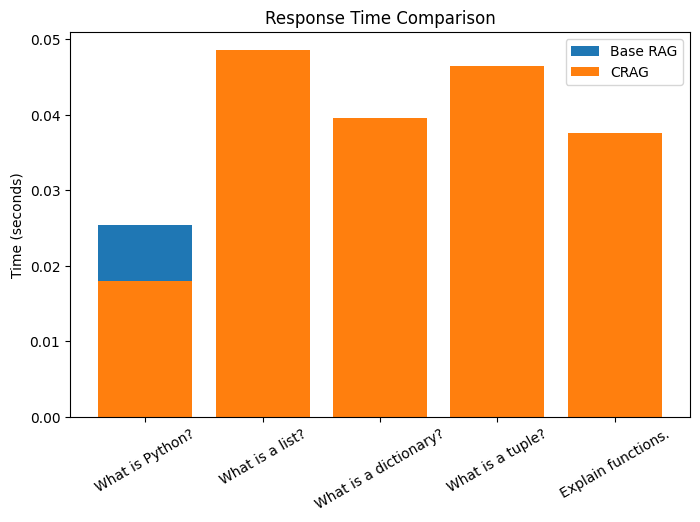

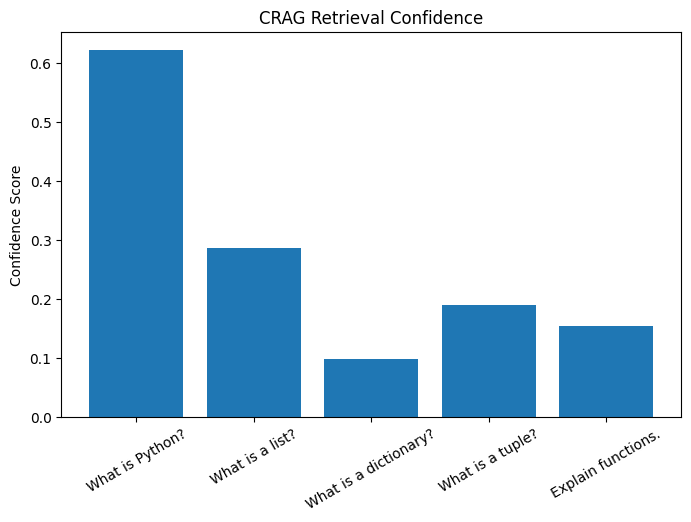

In [11]:

# Performance Visualizations

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Question"], df["Base_Time"], label="Base RAG")
plt.bar(df["Question"], df["CRAG_Time"], label="CRAG")
plt.xticks(rotation=30)
plt.ylabel("Time (seconds)")
plt.title("Response Time Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(df["Question"], df["CRAG_Confidence"])
plt.xticks(rotation=30)
plt.ylabel("Confidence Score")
plt.title("CRAG Retrieval Confidence")
plt.show()
